# AMR Data Integration & Preprocessing Pipeline
**Track B — Antibiotic Resistance Prediction (CodeCure Biohackathon)**

### Pipeline overview
1. Load & audit all 3 sources (Kaggle, Mendeley, CARD)
2. Clean Kaggle — standardise R/I/S, parse metadata, clean species names
3. Clean Mendeley — convert disk-diffusion mm → R/I/S via EUCAST v14 breakpoints
4. Merge: Kaggle as base, Mendeley appended (`-1` = not-tested sentinel for missing antibiotics)
5. Engineer resistance features (drug-class counts, MDR flags, cross-resistance)
6. **CARD enrichment — phenotype-driven** (isolate resistance profile → gene families)
7. Handle missing values — clinical metadata imputation with source flags
8. Final clean-up & sanity checks
9. EDA — distributions, heatmaps, MDR analysis
10. Antibiotic clustering into 4 drug-class groups
11. Save `amr_final_v2.csv`

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SENTINEL = -1   # 'not tested' — never impute resistance labels
RNG = 42

## 1. Load & Audit Sources

In [2]:
# ── Kaggle multi-resistance clinical dataset ───────────────────
kaggle_df = pd.read_csv('Data/Bacteria_dataset_Multiresictance.csv')
print(f'Kaggle  : {kaggle_df.shape[0]:>6} rows × {kaggle_df.shape[1]} cols')
print(f'  NaN counts per col (top 5):')
print(kaggle_df.isnull().sum().sort_values(ascending=False).head())

# ── Mendeley disk-diffusion dataset ───────────────────────────
mendeley_df = pd.read_excel('Data/Dataset.xlsx')
print(f'\nMendeley: {mendeley_df.shape[0]:>6} rows × {mendeley_df.shape[1]} cols')
print(mendeley_df.head(3))

# ── CARD ARO index ─────────────────────────────────────────────
card_df = pd.read_csv('Data/aro_index.tsv', sep='\t')
card_df['drug_class_lower']  = card_df['Drug Class'].str.lower().fillna('')
card_df['mechanism_lower']   = card_df['Resistance Mechanism'].str.lower().fillna('')
card_df['gene_family_lower'] = card_df['AMR Gene Family'].str.lower().fillna('')
print(f'\nCARD    : {card_df.shape[0]:>6} ARO entries')
print(f'  Unique gene families : {card_df["gene_family_lower"].nunique()}')
print(f'  Unique drug classes  : {card_df["drug_class_lower"].nunique()}')

Kaggle  :  10710 rows × 27 cols
  NaN counts per col (top 5):
Collection_Date    669
AMX/AMP            658
GEN                643
Souches            640
Co-trimoxazole     640
dtype: int64

Mendeley:    274 rows × 6 cols
  Location  IMIPENEM  CEFTAZIDIME  GENTAMICIN  AUGMENTIN  CIPROFLOXACIN
0    IFE-T        25           20          20         15             28
1    IFE-T        25           25          20         20             30
2    IFE-T        30           10          20         20             25

CARD    :   6445 ARO entries
  Unique gene families : 540
  Unique drug classes  : 161


## 2. Clean Kaggle Dataset

In [3]:
# ── 2a. Rename columns ────────────────────────────────────────
KAGGLE_AB_RENAME = {
    'AMX/AMP'          : 'amoxicillin_ampicillin',
    'AMC'              : 'amoxicillin_clavulanate',
    'CZ'               : 'cefazolin',
    'FOX'              : 'cefoxitin',
    'CTX/CRO'          : 'cefotaxime_ceftriaxone',
    'IPM'              : 'imipenem',
    'GEN'              : 'gentamicin',
    'AN'               : 'amikacin',
    'Acide nalidixique': 'nalidixic_acid',
    'ofx'              : 'ofloxacin',
    'CIP'              : 'ciprofloxacin',
    'C'                : 'chloramphenicol',
    'Co-trimoxazole'   : 'cotrimoxazole',
    'Furanes'          : 'nitrofurantoin',
    'colistine'        : 'colistin',
}
KAGGLE_META_RENAME = {
    'ID'             : 'patient_id',
    'Name'           : 'patient_name',
    'Email'          : 'patient_email',
    'Address'        : 'patient_address',
    'age/gender'     : 'age_gender',
    'Souches'        : 'bacteria_strain_raw',
    'Diabetes'       : 'has_diabetes',
    'Hypertension'   : 'has_hypertension',
    'Hospital_before': 'prior_hospitalisation',
    'Infection_Freq' : 'infection_frequency',
    'Collection_Date': 'collection_date',
    'Notes'          : 'notes',
}
kaggle_df.rename(columns={**KAGGLE_AB_RENAME, **KAGGLE_META_RENAME}, inplace=True)
KAGGLE_AB_COLS = list(KAGGLE_AB_RENAME.values())
print(f'Antibiotic columns ({len(KAGGLE_AB_COLS)}): {KAGGLE_AB_COLS}')

Antibiotic columns (15): ['amoxicillin_ampicillin', 'amoxicillin_clavulanate', 'cefazolin', 'cefoxitin', 'cefotaxime_ceftriaxone', 'imipenem', 'gentamicin', 'amikacin', 'nalidixic_acid', 'ofloxacin', 'ciprofloxacin', 'chloramphenicol', 'cotrimoxazole', 'nitrofurantoin', 'colistin']


In [4]:
# ── 2b. Encode R/I/S → 2/1/0, missing → SENTINEL (-1) ───────
RIS_MAP = {'r': 2, 'resistant': 2, 'i': 1, 'intermediate': 1, 's': 0, 'susceptible': 0}

def encode_ris(val):
    if pd.isna(val): return SENTINEL
    cleaned = str(val).strip().lower()
    if cleaned in ('', '?', 'missing', 'nan', 'none', 'nd', '-'): return SENTINEL
    return RIS_MAP.get(cleaned, SENTINEL)

for col in KAGGLE_AB_COLS:
    before = kaggle_df[col].isna().sum()
    kaggle_df[col] = kaggle_df[col].apply(encode_ris)
    sent  = (kaggle_df[col] == SENTINEL).sum()
    print(f'  {col:<35}  nulls_before={before:>4}  sentinel_after={sent:>4}')

# Sanity check
for col in KAGGLE_AB_COLS:
    bad = set(kaggle_df[col].unique()) - {0, 1, 2, SENTINEL}
    if bad: print(f'  WARNING unexpected values in {col}: {bad}')

  amoxicillin_ampicillin               nulls_before= 658  sentinel_after= 753
  amoxicillin_clavulanate              nulls_before= 632  sentinel_after= 753
  cefazolin                            nulls_before= 628  sentinel_after= 753
  cefoxitin                            nulls_before= 625  sentinel_after= 753
  cefotaxime_ceftriaxone               nulls_before= 624  sentinel_after= 753
  imipenem                             nulls_before= 633  sentinel_after= 753
  gentamicin                           nulls_before= 643  sentinel_after= 753
  amikacin                             nulls_before= 628  sentinel_after= 753
  nalidixic_acid                       nulls_before= 622  sentinel_after= 753
  ofloxacin                            nulls_before= 618  sentinel_after= 753
  ciprofloxacin                        nulls_before= 633  sentinel_after= 753
  chloramphenicol                      nulls_before= 629  sentinel_after= 753
  cotrimoxazole                        nulls_before= 640  sentin

In [5]:
# ── 2c. Parse clinical metadata ───────────────────────────────
def parse_age(val):
    if pd.isna(val): return np.nan
    digits = re.findall(r'\d+', str(val))
    return int(digits[0]) if digits else np.nan

def parse_gender(val):
    if pd.isna(val): return np.nan
    v = str(val).upper()
    if 'F' in v: return 'F'
    if 'M' in v: return 'M'
    return np.nan

kaggle_df['age']    = kaggle_df['age_gender'].apply(parse_age)
kaggle_df['gender'] = kaggle_df['age_gender'].apply(parse_gender)
kaggle_df.loc[~kaggle_df['age'].between(0, 120), 'age'] = np.nan

def to_binary(val):
    if pd.isna(val): return np.nan
    v = str(val).strip().lower()
    if v in ('yes', '1', 'true', 'oui', 'y'):  return 1.0
    if v in ('no',  '0', 'false', 'non', 'n'): return 0.0
    return np.nan

for col in ['has_diabetes', 'has_hypertension', 'prior_hospitalisation']:
    kaggle_df[col] = kaggle_df[col].apply(to_binary)

print('Clinical metadata parsed — age, gender, binary comorbidities')

Clinical metadata parsed — age, gender, binary comorbidities


In [6]:
# ── 2d. Clean species names ───────────────────────────────────
SPECIES_SYNONYMS = {
    'e. coli': 'escherichia coli', 'e.coli': 'escherichia coli',
    'e.coi': 'escherichia coli', 'e.cli': 'escherichia coli',
    'escherichia coli': 'escherichia coli',
    'enterobacteria spp.': 'escherichia coli',
    'enteobacteria spp.': 'escherichia coli',
    'klebsiella pneumoniae': 'klebsiella pneumoniae',
    'klbsiella pneumoniae': 'klebsiella pneumoniae',
    'klebsie.lla pneumoniae': 'klebsiella pneumoniae',
    'proteus mirabilis': 'proteus mirabilis',
    'protus mirabilis': 'proteus mirabilis',
    'proeus mirabilis': 'proteus mirabilis',
    'p. mirabilis': 'proteus mirabilis',
    'p. aeruginosa': 'pseudomonas aeruginosa',
    'pseudomonas aeruginosa': 'pseudomonas aeruginosa',
    'a. baumannii': 'acinetobacter baumannii',
    'acinetobacter baumannii': 'acinetobacter baumannii',
    'morganella morganii': 'morganella morganii',
    'citrobacter freundii': 'citrobacter freundii',
    'citrobacter spp.': 'citrobacter freundii',
    'serratia marcescens': 'serratia marcescens',
    'enterobacter cloacae': 'enterobacter cloacae',
    'e. cloacae': 'enterobacter cloacae',
}

def clean_species(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if val in ('?', 'missing', 'nan', '', 'none'): return np.nan
    val = re.sub(r'^S\d+\s+', '', val).strip().lower()
    return SPECIES_SYNONYMS.get(val, val)

kaggle_df['bacteria_strain'] = kaggle_df['bacteria_strain_raw'].apply(clean_species)
print('Species distribution after cleaning:')
print(kaggle_df['bacteria_strain'].value_counts(dropna=False).head(15).to_string())

Species distribution after cleaning:
bacteria_strain
escherichia coli           6980
NaN                         763
klebsiella pneumoniae       702
proteus mirabilis           696
citrobacter freundii        481
morganella morganii         305
serratia marcescens         256
pseudomonas aeruginosa      200
acinetobacter baumannii     181
enter.bacteria spp.         100
prot.eus mirabilis           46


In [7]:
# ── 2e. Drop rows with fewer than 2 tested antibiotics ────────
n_before = len(kaggle_df)
tested   = kaggle_df[KAGGLE_AB_COLS].ne(SENTINEL).sum(axis=1)
kaggle_df = kaggle_df[tested >= 2].reset_index(drop=True)
print(f'Rows before: {n_before}  →  after (≥2 tested antibiotics): {len(kaggle_df)}')

KAGGLE_KEEP = (['bacteria_strain', 'age', 'gender',
                'has_diabetes', 'has_hypertension', 'prior_hospitalisation']
               + KAGGLE_AB_COLS)
KAGGLE_KEEP = [c for c in KAGGLE_KEEP if c in kaggle_df.columns]
kaggle_final = kaggle_df[KAGGLE_KEEP].copy()
kaggle_final['source'] = 'kaggle'

Rows before: 10710  →  after (≥2 tested antibiotics): 9957


## 3. Clean Mendeley Dataset

In [8]:
# Mendeley has only 4 antibiotics recorded as disk-diffusion zone diameters (mm)
# EUCAST v14 breakpoints for Enterobacterales, disk diffusion
MENDELEY_AB_RENAME = {
    'IMIPENEM'     : 'imipenem',
    'CEFTAZIDIME'  : 'ceftazidime',        # not in Kaggle — we keep and drop later
    'GENTAMICIN'   : 'gentamicin',
    'AUGMENTIN'    : 'amoxicillin_clavulanate',
    'CIPROFLOXACIN': 'ciprofloxacin',
}
mendeley_df.rename(columns=MENDELEY_AB_RENAME, inplace=True)
mendeley_df.rename(columns={'Location': 'sample_location'}, inplace=True)
MENDELEY_AB_COLS = list(MENDELEY_AB_RENAME.values())

EUCAST_BP = {
    'imipenem'               : {'S': 22, 'R': 19},
    'ceftazidime'            : {'S': 21, 'R': 17},
    'gentamicin'             : {'S': 18, 'R': 14},
    'amoxicillin_clavulanate': {'S': 18, 'R': 14},
    'ciprofloxacin'          : {'S': 25, 'R': 21},
}

def mm_to_ris(val, antibiotic):
    if pd.isna(val): return SENTINEL
    try:   v = float(str(val).strip())
    except ValueError: return SENTINEL
    bp = EUCAST_BP[antibiotic]
    if v >= bp['S']:   return 0   # Susceptible
    elif v <= bp['R']: return 2   # Resistant
    else:              return 1   # Intermediate

for col in MENDELEY_AB_COLS:
    mendeley_df[col] = mendeley_df[col].apply(lambda x: mm_to_ris(x, col))
    dist = mendeley_df[col].value_counts().to_dict()
    label = {-1:'NT', 0:'S', 1:'I', 2:'R'}
    print(f'  {col:<35} { {label.get(k,k): v for k,v in sorted(dist.items())} }')

# Build Mendeley final — fill all 15 Kaggle antibiotics not in Mendeley with SENTINEL
mendeley_final = mendeley_df[MENDELEY_AB_COLS].copy()
kaggle_only_ab = [c for c in KAGGLE_AB_COLS if c not in MENDELEY_AB_COLS]
for col in kaggle_only_ab:
    mendeley_final[col] = SENTINEL
# NOTE: ceftazidime is Mendeley-only — we keep it for now; it will get its own column

mendeley_final['source']          = 'mendeley'
mendeley_final['bacteria_strain'] = np.nan  # no species info in Mendeley
for col in ['age','gender','has_diabetes','has_hypertension','prior_hospitalisation']:
    mendeley_final[col] = np.nan

print(f'\nMendeley final: {mendeley_final.shape}')

  imipenem                            {'S': 180, 'I': 60, 'R': 34}
  ceftazidime                         {'S': 30, 'I': 33, 'R': 211}
  gentamicin                          {'S': 149, 'I': 68, 'R': 57}
  amoxicillin_clavulanate             {'S': 63, 'I': 46, 'R': 165}
  ciprofloxacin                       {'S': 73, 'I': 61, 'R': 140}

Mendeley final: (274, 23)


## 4. Merge Datasets

In [9]:
# Align to the same 15-antibiotic schema + shared meta
# NOTE: Mendeley's ceftazidime maps to cefotaxime_ceftriaxone category (3rd-gen ceph)
# We reconcile this by using ceftazidime values to fill cefotaxime_ceftriaxone for
# Mendeley rows (same EUCAST breakpoint context), then dropping ceftazidime
mendeley_final['cefotaxime_ceftriaxone'] = mendeley_final['ceftazidime']
mendeley_final.drop(columns=['ceftazidime'], inplace=True, errors='ignore')
# NOTE: cefazolin, cefoxitin, amoxicillin_ampicillin etc. remain SENTINEL for Mendeley

ALL_AB_COLS = KAGGLE_AB_COLS  # 15 canonical antibiotic columns

SHARED_COLS = (
    ['source', 'bacteria_strain', 'age', 'gender',
     'has_diabetes', 'has_hypertension', 'prior_hospitalisation']
    + ALL_AB_COLS
)

def align_cols(df, cols):
    for c in cols:
        if c not in df.columns: df[c] = np.nan
    return df[cols].copy()

merged = pd.concat(
    [align_cols(kaggle_final, SHARED_COLS),
     align_cols(mendeley_final, SHARED_COLS)],
    ignore_index=True
)

# Ensure antibiotic cols are int (all values are -1/0/1/2)
for col in ALL_AB_COLS:
    merged[col] = pd.to_numeric(merged[col], errors='coerce').fillna(SENTINEL).astype(int)

print(f'Kaggle rows   : {(merged["source"]=="kaggle").sum()}')
print(f'Mendeley rows : {(merged["source"]=="mendeley").sum()}')
print(f'Merged total  : {len(merged)}  ×  {merged.shape[1]} cols')

print('\nAntibiotic value distribution (all rows):')
for col in ALL_AB_COLS:
    vc = merged[col].value_counts(dropna=False).to_dict()
    labels = {-1:'NT', 0:'S', 1:'I', 2:'R'}
    print(f'  {col:<35} { {labels.get(k,k): v for k,v in sorted(vc.items())} }')

Kaggle rows   : 9957
Mendeley rows : 274
Merged total  : 10231  ×  22 cols

Antibiotic value distribution (all rows):
  amoxicillin_ampicillin              {'NT': 274, 'S': 4061, 'I': 184, 'R': 5712}
  amoxicillin_clavulanate             {'S': 4033, 'I': 218, 'R': 5980}
  cefazolin                           {'NT': 274, 'S': 4097, 'I': 170, 'R': 5690}
  cefoxitin                           {'NT': 274, 'S': 4049, 'I': 173, 'R': 5735}
  cefotaxime_ceftriaxone              {'S': 4056, 'I': 216, 'R': 5959}
  imipenem                            {'S': 4234, 'I': 246, 'R': 5751}
  gentamicin                          {'S': 8003, 'I': 235, 'R': 1993}
  amikacin                            {'NT': 274, 'S': 7875, 'I': 177, 'R': 1905}
  nalidixic_acid                      {'NT': 274, 'S': 8379, 'I': 190, 'R': 1388}
  ofloxacin                           {'NT': 274, 'S': 8406, 'I': 170, 'R': 1381}
  ciprofloxacin                       {'S': 8404, 'I': 240, 'R': 1587}
  chloramphenicol                  

## 5. Engineer Resistance Features

In [10]:
# Drug-class groupings (used for clustering labels too)
DRUG_CLASSES = {
    'beta_lactam'   : ['amoxicillin_ampicillin', 'amoxicillin_clavulanate',
                       'cefazolin', 'cefoxitin', 'cefotaxime_ceftriaxone', 'imipenem'],
    'aminoglycoside': ['gentamicin', 'amikacin'],
    'quinolone'     : ['nalidixic_acid', 'ofloxacin', 'ciprofloxacin'],
    'other'         : ['chloramphenicol', 'cotrimoxazole', 'nitrofurantoin', 'colistin'],
}

for cls, cols in DRUG_CLASSES.items():
    present = [c for c in cols if c in merged.columns]
    # Only count tested antibiotics (exclude sentinel -1)
    vals = merged[present].replace(SENTINEL, np.nan)
    merged[f'n_resistant_{cls}']   = vals.eq(2).sum(axis=1)
    merged[f'n_tested_{cls}']      = vals.notna().sum(axis=1)
    merged[f'pct_resistant_{cls}'] = (
        merged[f'n_resistant_{cls}'] / merged[f'n_tested_{cls}']
    ).round(3).fillna(0)

# Overall resistance burden
all_vals = merged[ALL_AB_COLS].replace(SENTINEL, np.nan)
merged['total_resistant']          = all_vals.eq(2).sum(axis=1)
merged['total_antibiotics_tested'] = all_vals.notna().sum(axis=1)
merged['overall_resistance_rate']  = (
    merged['total_resistant'] / merged['total_antibiotics_tested']
).round(3).fillna(0)

# MDR = resistant to ≥3 antibiotic classes (WHO definition)
class_resistant = {}
for cls, cols in DRUG_CLASSES.items():
    present = [c for c in cols if c in merged.columns]
    class_resistant[cls] = merged[present].eq(2).any(axis=1).astype(int)
merged['n_classes_resistant'] = sum(class_resistant.values())
merged['is_mdr']              = (merged['n_classes_resistant'] >= 3).astype(int)

# Critical MDR — resistant to a WHO Reserve antibiotic
merged['is_critical_mdr'] = (
    (merged['imipenem'] == 2) | (merged['colistin'] == 2)
).astype(int)

# Clinically meaningful cross-resistance flags
merged['phenotype_esbl'] = (
    (merged['cefotaxime_ceftriaxone'] == 2) & (merged['imipenem'] != 2)
).astype(int)
merged['phenotype_carbapenemase']   = (merged['imipenem'] == 2).astype(int)
merged['phenotype_colistin_r']      = (merged['colistin'] == 2).astype(int)
merged['phenotype_fq_r']            = (merged['ciprofloxacin'] == 2).astype(int)
merged['phenotype_aminoglyco_r']    = (
    (merged['gentamicin'] == 2) | (merged['amikacin'] == 2)
).astype(int)
merged['quinolone_cross_resistance'] = (
    (merged['ciprofloxacin'] == 2) & (merged['nalidixic_acid'] == 2)
).astype(int)
merged['dual_carbapenem_aminoglyco'] = (
    (merged['imipenem'] == 2) & (merged['phenotype_aminoglyco_r'] == 1)
).astype(int)

print('Engineered features added:')
eng_cols = [c for c in merged.columns
            if any(c.startswith(p) for p in
                   ['n_resistant','n_tested','pct_','total_','overall_',
                    'is_','phenotype_','quinolone_','dual_','n_classes'])]
print(f'  {len(eng_cols)} columns: {eng_cols}')

Engineered features added:
  25 columns: ['n_resistant_beta_lactam', 'n_tested_beta_lactam', 'pct_resistant_beta_lactam', 'n_resistant_aminoglycoside', 'n_tested_aminoglycoside', 'pct_resistant_aminoglycoside', 'n_resistant_quinolone', 'n_tested_quinolone', 'pct_resistant_quinolone', 'n_resistant_other', 'n_tested_other', 'pct_resistant_other', 'total_resistant', 'total_antibiotics_tested', 'overall_resistance_rate', 'n_classes_resistant', 'is_mdr', 'is_critical_mdr', 'phenotype_esbl', 'phenotype_carbapenemase', 'phenotype_colistin_r', 'phenotype_fq_r', 'phenotype_aminoglyco_r', 'quinolone_cross_resistance', 'dual_carbapenem_aminoglyco']


## 6. CARD Enrichment — Phenotype-Driven (Isolate-Level)

**Key design change from v1:**
- v1 mapped `species → CARD genes` → every *E. coli* got identical features (94%+ positive, near-zero variance, useless)
- v2 maps `observed_resistance_phenotype → CARD` — each isolate gets features based on *what it actually resists*
- This gives real isolate-level variance and biologically meaningful signal

Logic: if an isolate is **Resistant** to a drug class, we look up CARD for gene families
known to confer resistance to that class. We then count/flag those gene families.

In [11]:
# ── Map antibiotic column → CARD drug class keywords ──────────
# When an isolate is Resistant (==2) to this antibiotic,
# we search CARD for genes conferring resistance to these drug classes
PHENO_TO_CARD_CLASS = {
    'amoxicillin_ampicillin'   : ['penicillin'],
    'amoxicillin_clavulanate'  : ['penicillin', 'clavulanic acid'],
    'cefazolin'                : ['cephalosporin'],
    'cefoxitin'                : ['cephalosporin'],
    'cefotaxime_ceftriaxone'   : ['cephalosporin', 'monobactam'],
    'imipenem'                 : ['carbapenem'],
    'gentamicin'               : ['aminoglycoside antibiotic'],
    'amikacin'                 : ['aminoglycoside antibiotic'],
    'nalidixic_acid'           : ['fluoroquinolone antibiotic'],
    'ofloxacin'                : ['fluoroquinolone antibiotic'],
    'ciprofloxacin'            : ['fluoroquinolone antibiotic'],
    'chloramphenicol'          : ['phenicol antibiotic'],
    'cotrimoxazole'            : ['diaminopyrimidine antibiotic', 'sulfonamide'],
    'nitrofurantoin'           : ['nitrofuran antibiotic'],
    'colistin'                 : ['peptide antibiotic', 'polymyxin'],
}

# High-value specific gene families to flag explicitly
KEY_GENE_FAMILIES = {
    'card_has_ctx_m'       : 'ctx-m beta-lactamase',
    'card_has_tem'         : 'tem beta-lactamase',
    'card_has_kpc'         : 'kpc beta-lactamase',
    'card_has_ndm'         : 'ndm beta-lactamase',
    'card_has_vim'         : 'vim beta-lactamase',
    'card_has_imp'         : 'imp beta-lactamase',
    'card_has_oxa_48'      : 'oxa-48-like beta-lactamase',
    'card_has_mcr'         : 'mcr phosphoethanolamine',
    'card_has_qnr'         : 'quinolone resistance protein',
    'card_has_aac'         : 'aac(',   # matches aac(6'), aac(3), aac(2')
    'card_has_rnd_efflux'  : 'resistance-nodulation-cell division (rnd)',
    'card_has_mfs_efflux'  : 'major facilitator superfamily (mfs)',
}

def compute_card_features(row):
    """Compute CARD features for ONE isolate based on its resistance phenotype."""
    # Step 1: collect CARD drug classes implied by observed resistance
    active_classes = set()
    for ab_col, drug_classes in PHENO_TO_CARD_CLASS.items():
        if row.get(ab_col, SENTINEL) == 2:   # Resistant
            active_classes.update(drug_classes)

    result = {}

    if not active_classes:
        # No resistance observed (susceptible/not-tested isolate) → all zeros
        result['card_n_active_drug_classes']  = 0
        result['card_relevant_gene_count']    = 0
        result['card_mechanism_diversity']    = 0
        result['card_gene_family_diversity']  = 0
        result['card_has_inactivation']       = 0
        result['card_has_efflux']             = 0
        result['card_has_target_alteration']  = 0
        result['card_has_target_protection']  = 0
        result['card_has_reduced_permeability'] = 0
        for feat in KEY_GENE_FAMILIES:
            result[feat] = 0
        return result

    # Step 2: filter CARD to only genes relevant to this isolate's resistance
    pattern = '|'.join(re.escape(c) for c in active_classes)
    matching = card_df[card_df['drug_class_lower'].str.contains(pattern, na=False)]

    all_mech  = ' '.join(matching['mechanism_lower'].dropna())
    all_gene  = ' '.join(matching['gene_family_lower'].dropna())

    # Step 3: diversity counts (continuous, informative)
    result['card_n_active_drug_classes'] = len(active_classes)
    result['card_relevant_gene_count']   = len(matching)
    result['card_mechanism_diversity']   = matching['mechanism_lower'].nunique()
    result['card_gene_family_diversity'] = matching['gene_family_lower'].nunique()

    # Step 4: resistance mechanism flags (from actual observed drug classes)
    result['card_has_inactivation']         = int('antibiotic inactivation' in all_mech)
    result['card_has_efflux']               = int('antibiotic efflux' in all_mech)
    result['card_has_target_alteration']    = int('target alteration' in all_mech)
    result['card_has_target_protection']    = int('target protection' in all_mech)
    result['card_has_reduced_permeability'] = int('reduced permeability' in all_mech)

    # Step 5: specific clinically important gene family flags
    for feat, keyword in KEY_GENE_FAMILIES.items():
        result[feat] = int(keyword in all_gene)

    return result

print('Computing phenotype-driven CARD features (row-wise)...')
card_feat_df = merged.apply(
    lambda row: pd.Series(compute_card_features(row)), axis=1
).fillna(0).astype(int)

df = pd.concat([merged.reset_index(drop=True), card_feat_df.reset_index(drop=True)], axis=1)

CARD_COLS = list(card_feat_df.columns)
print(f'\nCARD features added: {len(CARD_COLS)}')
print('\nVariance check (should NOT be all 94%+):')
for col in CARD_COLS:
    if df[col].dtype == int or df[col].nunique() <= 5:
        vc = df[col].value_counts(normalize=True).round(3).to_dict()
        print(f'  {col:<35} {vc}')

Computing phenotype-driven CARD features (row-wise)...

CARD features added: 21

Variance check (should NOT be all 94%+):
  card_n_active_drug_classes          {5: 0.171, 6: 0.163, 4: 0.151, 3: 0.121, 7: 0.106, 2: 0.094, 8: 0.066, 1: 0.048, 9: 0.036, 0: 0.024, 10: 0.013, 11: 0.005, 12: 0.002, 13: 0.0}
  card_relevant_gene_count            {5032: 0.06, 5271: 0.044, 4843: 0.044, 5314: 0.038, 4839: 0.026, 5536: 0.026, 5028: 0.025, 0: 0.024, 3124: 0.022, 5083: 0.021, 5126: 0.019, 3429: 0.019, 3422: 0.017, 4439: 0.014, 5310: 0.014, 5122: 0.014, 5036: 0.013, 5111: 0.012, 5267: 0.012, 5348: 0.011, 5149: 0.011, 5393: 0.011, 5630: 0.01, 4435: 0.01, 5341: 0.01, 5373: 0.009, 312: 0.009, 5079: 0.009, 4000: 0.008, 3714: 0.008, 5273: 0.008, 3677: 0.008, 3707: 0.008, 3413: 0.007, 2600: 0.007, 3670: 0.007, 5604: 0.007, 5427: 0.006, 5634: 0.006, 5391: 0.006, 5538: 0.006, 5318: 0.006, 3373: 0.006, 5621: 0.005, 4963: 0.005, 4719: 0.005, 5841: 0.005, 5532: 0.005, 5700: 0.005, 4847: 0.005, 313: 0.005, 4723

## 7. Handle Missing Values — Clinical Metadata Imputation

In [12]:
# ── 7a. Source flag — always add before imputing ───────────────
# This tells the model which rows have imputed metadata
df['metadata_imputed'] = df['bacteria_strain'].isna().astype(int)

print(f'Rows with imputed metadata: {df["metadata_imputed"].sum()} '
      f'(all from Mendeley source)')

# ── 7b. bacteria_strain — classifier-based imputation ─────────
# We use the isolate\'s own resistance phenotype + CARD features
# to predict the most likely species
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Feature cols: use antibiotic results + phenotype flags + CARD diversity
# (not all CARD binary flags since Mendeley rows get theirs from phenotype too)
strain_feat_cols = (
    ALL_AB_COLS +
    ['phenotype_esbl','phenotype_carbapenemase','phenotype_colistin_r',
     'phenotype_fq_r','phenotype_aminoglyco_r',
     'n_classes_resistant','overall_resistance_rate',
     'card_mechanism_diversity','card_gene_family_diversity','card_n_active_drug_classes']
)

known   = df[df['bacteria_strain'].notna()].copy()
unknown = df[df['bacteria_strain'].isna()].copy()

le = LabelEncoder()
known['strain_enc'] = le.fit_transform(known['bacteria_strain'])

clf = RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1)
clf.fit(known[strain_feat_cols], known['strain_enc'])

pred_enc = clf.predict(unknown[strain_feat_cols])
pred_labels = le.inverse_transform(pred_enc)
df.loc[df['bacteria_strain'].isna(), 'bacteria_strain'] = pred_labels

print('bacteria_strain imputed via Random Forest on resistance phenotype')
print('\nFinal species distribution:')
print(df['bacteria_strain'].value_counts().to_string())

# ── 7c. Age — median imputation (by species for accuracy) ─────
df['age'] = df.groupby('bacteria_strain')['age'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback for any remaining NaN (if whole group is NaN)
df['age'].fillna(df['age'].median(), inplace=True)

# ── 7d. Gender — mode imputation ──────────────────────────────
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

# ── 7e. Binary comorbidities ──────────────────────────────────
# Impute with 0 (assume absent when unknown)
# Conservative: we do NOT want to inflate comorbidity signal for Mendeley rows
for col in ['has_diabetes', 'has_hypertension', 'prior_hospitalisation']:
    df[col].fillna(0.0, inplace=True)

# ── Final NaN check ───────────────────────────────────────────
print('\nFinal NaN counts:')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else '  None — dataset is complete!')

Rows with imputed metadata: 284 (all from Mendeley source)
bacteria_strain imputed via Random Forest on resistance phenotype

Final species distribution:
bacteria_strain
escherichia coli           7261
klebsiella pneumoniae       702
proteus mirabilis           697
citrobacter freundii        481
morganella morganii         306
serratia marcescens         257
pseudomonas aeruginosa      200
acinetobacter baumannii     181
enter.bacteria spp.         100
prot.eus mirabilis           46

Final NaN counts:
  None — dataset is complete!


## 8. Final Clean-up

In [13]:
# Drop low-value / PII columns
DROP_COLS = ['source']   # keep 'metadata_imputed' as proxy for source
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Encode gender as binary
df['gender_enc'] = (df['gender'] == 'F').astype(int)

# Encode species as integer label (for models that need numeric input)
le_species = LabelEncoder()
df['species_enc'] = le_species.fit_transform(df['bacteria_strain'])

print(f'Final dataset shape: {df.shape}')
print('\nColumn groups:')
ab_cols   = ALL_AB_COLS
meta_cols = ['bacteria_strain','age','gender_enc','has_diabetes',
             'has_hypertension','prior_hospitalisation','metadata_imputed','species_enc']
eng_cols  = [c for c in df.columns
             if any(c.startswith(p) for p in
                    ['n_resistant','n_tested','pct_','total_','overall_',
                     'is_','phenotype_','quinolone_','dual_','n_classes'])]
card_cols = CARD_COLS

print(f'  Antibiotic labels (R/I/S/-1) : {len(ab_cols)}')
print(f'  Clinical metadata            : {len([c for c in meta_cols if c in df.columns])}')
print(f'  Engineered features          : {len(eng_cols)}')
print(f'  CARD features (phenotype)    : {len(card_cols)}')
print(f'  Total columns                : {df.shape[1]}')
print(f'  Total rows                   : {df.shape[0]}')

Final dataset shape: (10231, 70)

Column groups:
  Antibiotic labels (R/I/S/-1) : 15
  Clinical metadata            : 8
  Engineered features          : 25
  CARD features (phenotype)    : 21
  Total columns                : 70
  Total rows                   : 10231


## 9. EDA

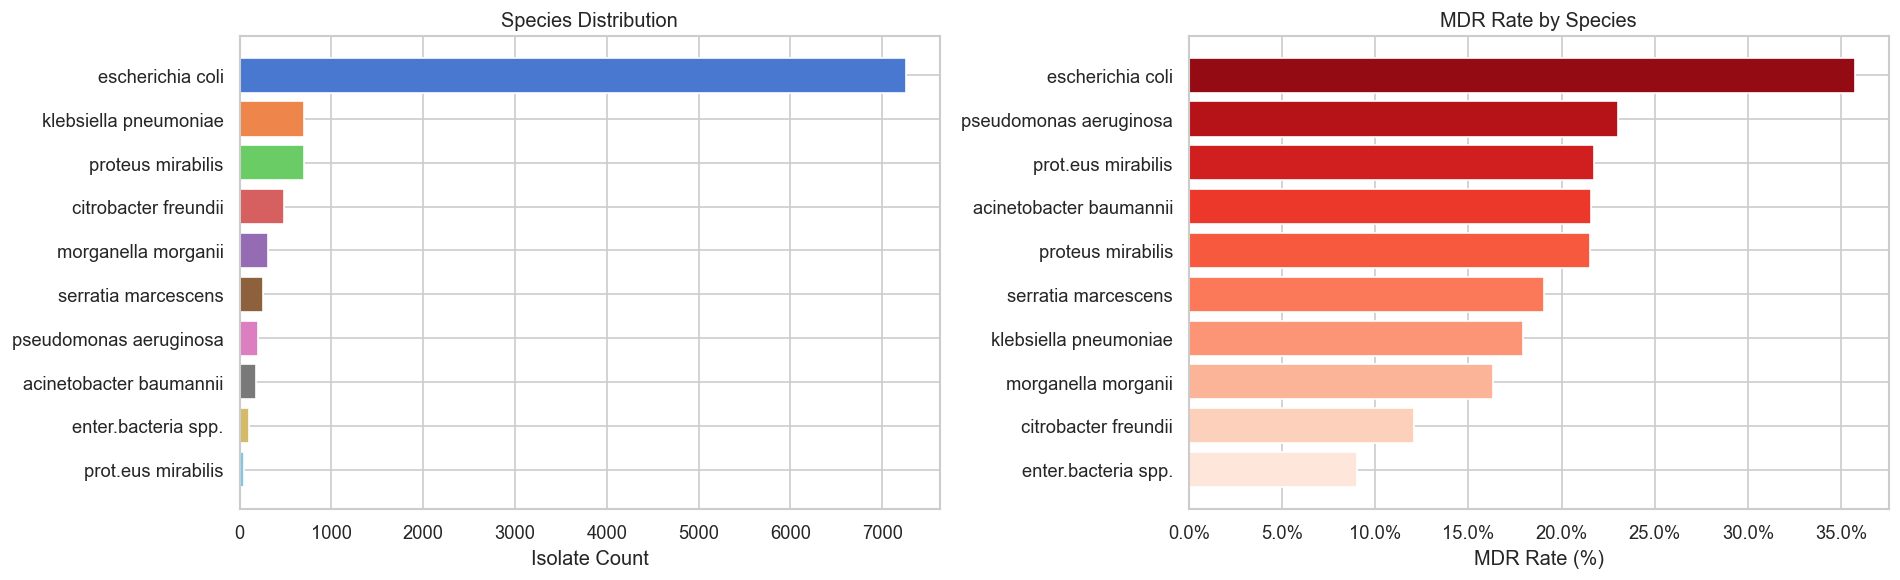

In [14]:
# ── 9a. Species distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

species_counts = df['bacteria_strain'].value_counts()
axes[0].barh(species_counts.index, species_counts.values, color=sns.color_palette('muted', len(species_counts)))
axes[0].set_xlabel('Isolate Count')
axes[0].set_title('Species Distribution')
axes[0].invert_yaxis()

# MDR by species
mdr_by_species = df.groupby('bacteria_strain')['is_mdr'].mean().sort_values(ascending=False)
axes[1].barh(mdr_by_species.index, mdr_by_species.values * 100,
             color=sns.color_palette('Reds_r', len(mdr_by_species)))
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel('MDR Rate (%)')
axes[1].set_title('MDR Rate by Species')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_species_mdr.png', bbox_inches='tight')
plt.show()

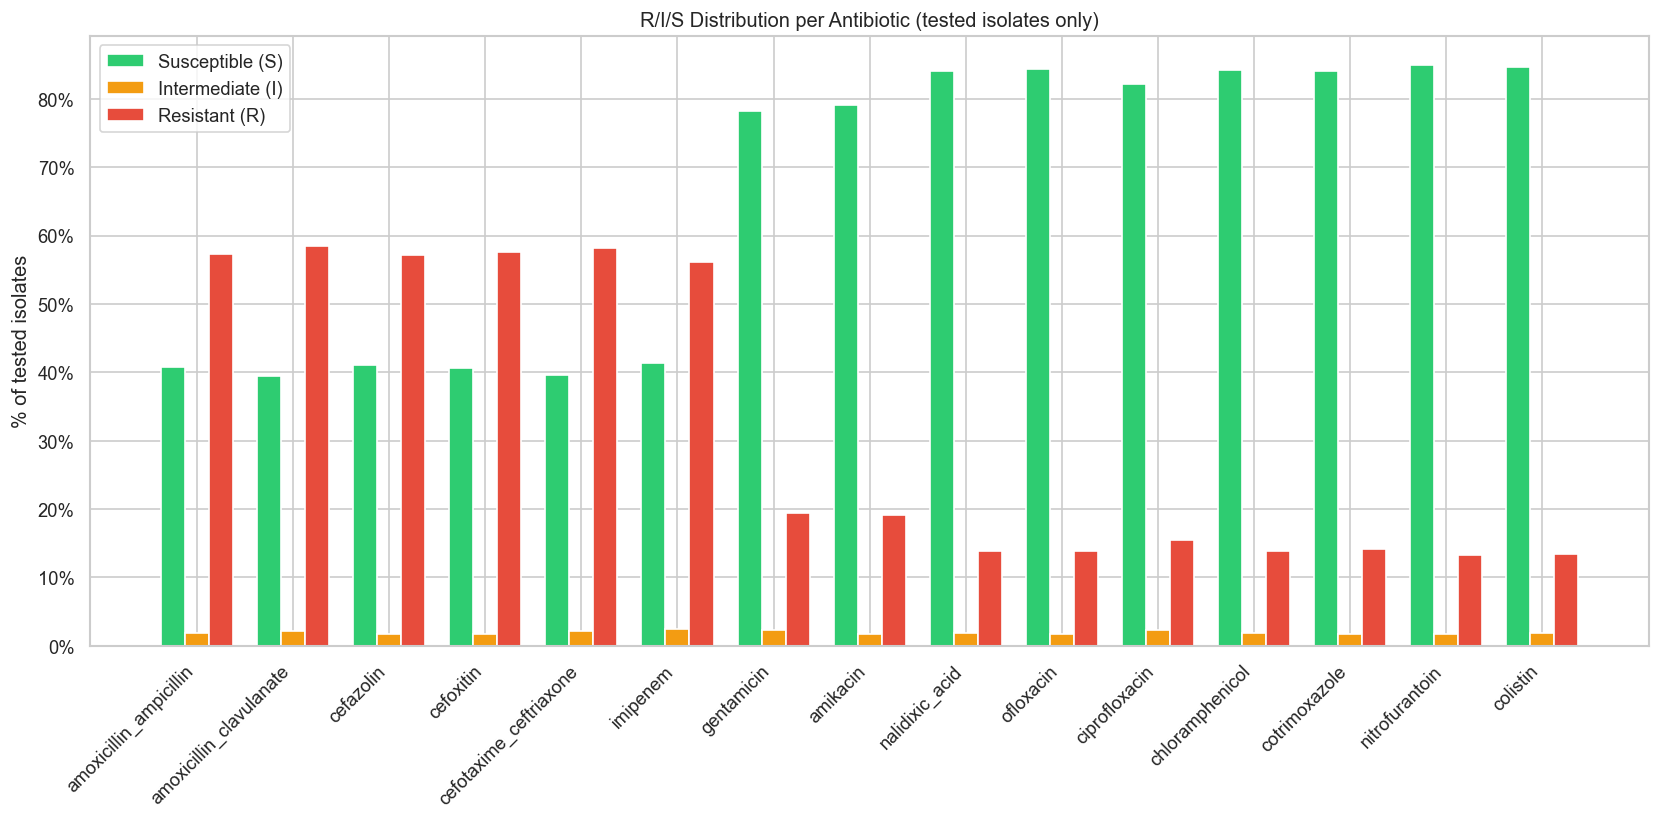


Not-tested (-1) counts per antibiotic:
  amoxicillin_ampicillin              NT=274 (2.7%)
  amoxicillin_clavulanate             NT=0 (0.0%)
  cefazolin                           NT=274 (2.7%)
  cefoxitin                           NT=274 (2.7%)
  cefotaxime_ceftriaxone              NT=0 (0.0%)
  imipenem                            NT=0 (0.0%)
  gentamicin                          NT=0 (0.0%)
  amikacin                            NT=274 (2.7%)
  nalidixic_acid                      NT=274 (2.7%)
  ofloxacin                           NT=274 (2.7%)
  ciprofloxacin                       NT=0 (0.0%)
  chloramphenicol                     NT=274 (2.7%)
  cotrimoxazole                       NT=274 (2.7%)
  nitrofurantoin                      NT=274 (2.7%)
  colistin                            NT=274 (2.7%)


In [15]:
# ── 9b. R/I/S balance per antibiotic (tested rows only) ───────
ris_data = {}
for col in ALL_AB_COLS:
    tested = df[df[col] != SENTINEL][col]
    counts = tested.value_counts(normalize=True)
    ris_data[col] = {
        'S': counts.get(0, 0) * 100,
        'I': counts.get(1, 0) * 100,
        'R': counts.get(2, 0) * 100
    }

ris_df = pd.DataFrame(ris_data).T

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ris_df))
w = 0.25
ax.bar(x - w, ris_df['S'], w, label='Susceptible (S)', color='#2ecc71')
ax.bar(x,     ris_df['I'], w, label='Intermediate (I)', color='#f39c12')
ax.bar(x + w, ris_df['R'], w, label='Resistant (R)', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(ris_df.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% of tested isolates')
ax.set_title('R/I/S Distribution per Antibiotic (tested isolates only)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_ris_distribution.png', bbox_inches='tight')
plt.show()

print('\nNot-tested (-1) counts per antibiotic:')
for col in ALL_AB_COLS:
    nt = (df[col] == SENTINEL).sum()
    print(f'  {col:<35} NT={nt} ({nt/len(df)*100:.1f}%)')

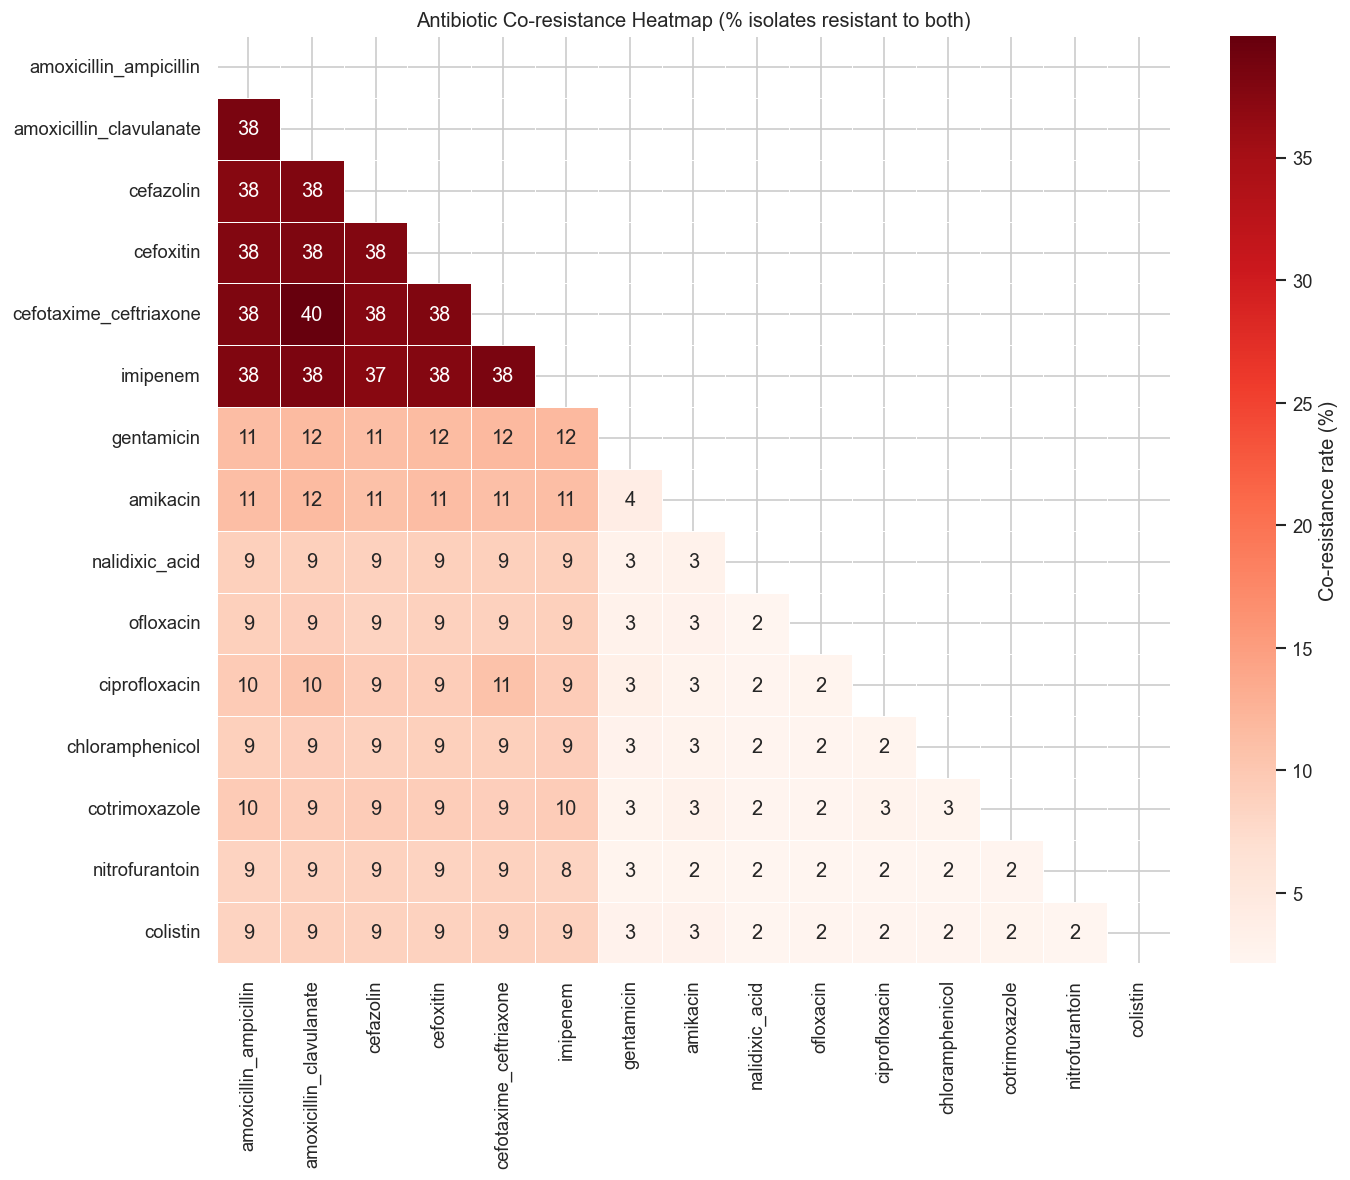

In [16]:
# ── 9c. Resistance co-occurrence heatmap ──────────────────────
# For each pair of antibiotics, % of isolates resistant to BOTH
resist = df[ALL_AB_COLS].copy()
resist.replace(SENTINEL, np.nan, inplace=True)
resist_binary = (resist == 2).astype(float)

co_res = resist_binary.T.dot(resist_binary) / len(df)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(co_res, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(co_res * 100, mask=mask, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-resistance rate (%)'})
ax.set_title('Antibiotic Co-resistance Heatmap (% isolates resistant to both)')
plt.tight_layout()
plt.savefig('eda_coresistance_heatmap.png', bbox_inches='tight')
plt.show()

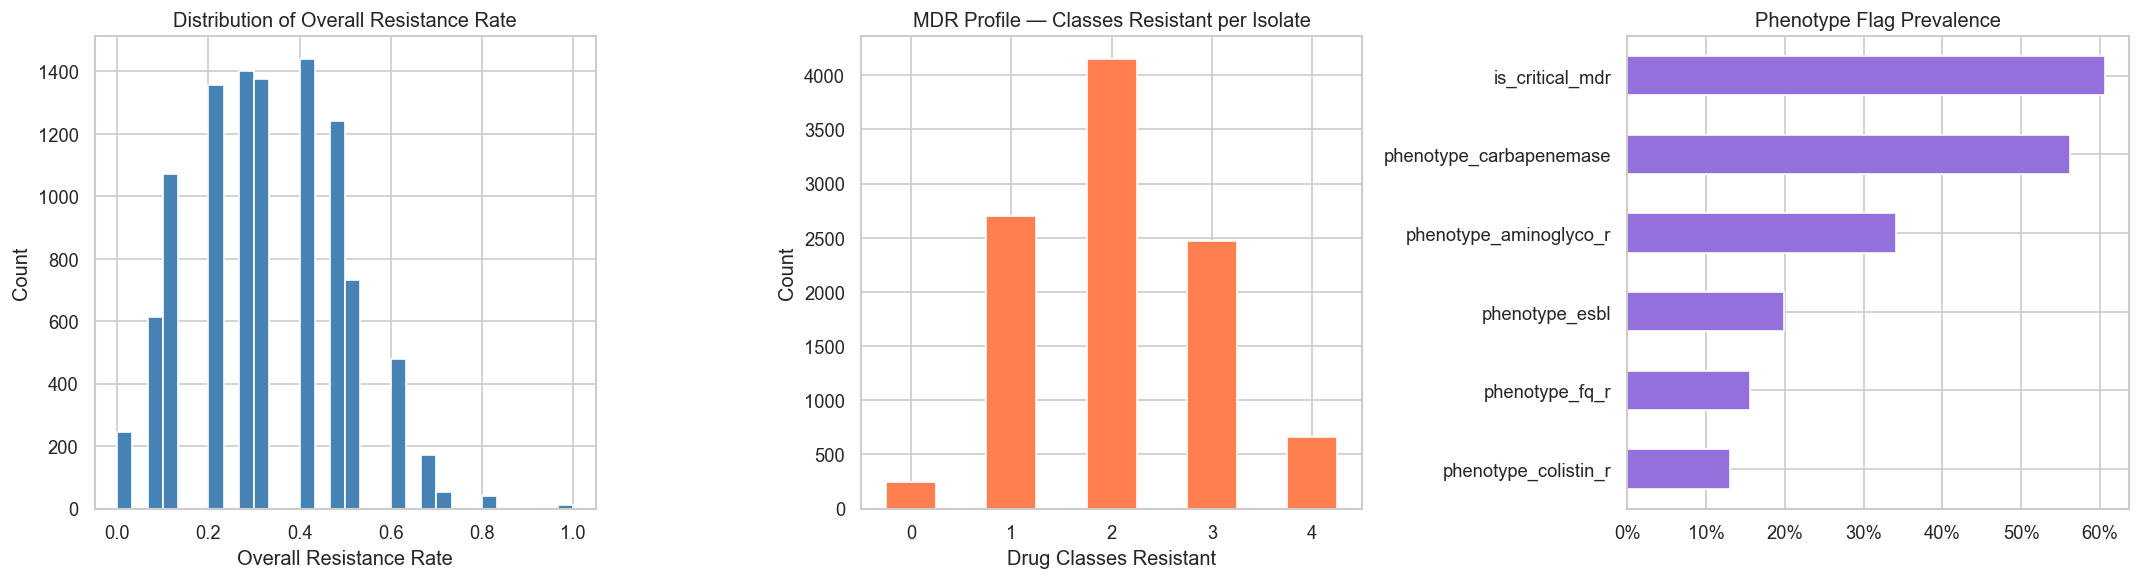


MDR isolates (≥3 classes): 3133 (30.6%)
Critical MDR (Reserve AB): 6202 (60.6%)


In [17]:
# ── 9d. MDR & resistance burden ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall resistance rate distribution
axes[0].hist(df['overall_resistance_rate'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Overall Resistance Rate')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Overall Resistance Rate')

# Number of drug classes resistant
df['n_classes_resistant'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white')
axes[1].set_xlabel('Drug Classes Resistant')
axes[1].set_ylabel('Count')
axes[1].set_title('MDR Profile — Classes Resistant per Isolate')
axes[1].tick_params(rotation=0)

# Phenotype flags prevalence
pheno_cols = ['phenotype_esbl','phenotype_carbapenemase','phenotype_colistin_r',
              'phenotype_fq_r','phenotype_aminoglyco_r','is_critical_mdr']
pheno_rates = df[pheno_cols].mean() * 100
pheno_rates.sort_values().plot(kind='barh', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_title('Phenotype Flag Prevalence')

plt.tight_layout()
plt.savefig('eda_mdr_burden.png', bbox_inches='tight')
plt.show()

print(f'\nMDR isolates (≥3 classes): {df["is_mdr"].sum()} ({df["is_mdr"].mean()*100:.1f}%)')
print(f'Critical MDR (Reserve AB): {df["is_critical_mdr"].sum()} ({df["is_critical_mdr"].mean()*100:.1f}%)')

In [18]:
# ── 9e. CARD feature variance check (should show real variance now) ──
print('CARD feature variance (phenotype-driven v2):')
binary_card = [c for c in CARD_COLS if df[c].nunique() <= 2]
for col in binary_card:
    vc = df[col].value_counts(normalize=True).round(3).to_dict()
    print(f'  {col:<40} {vc}')

print('\nContinuous CARD features stats:')
cont_card = [c for c in CARD_COLS if df[c].nunique() > 2]
print(df[cont_card].describe().round(2).to_string())

CARD feature variance (phenotype-driven v2):
  card_has_inactivation                    {1: 0.974, 0: 0.026}
  card_has_efflux                          {1: 0.976, 0: 0.024}
  card_has_target_alteration               {1: 0.976, 0: 0.024}
  card_has_target_protection               {0: 0.563, 1: 0.437}
  card_has_reduced_permeability            {1: 0.974, 0: 0.026}
  card_has_ctx_m                           {1: 0.947, 0: 0.053}
  card_has_tem                             {1: 0.947, 0: 0.053}
  card_has_kpc                             {1: 0.947, 0: 0.053}
  card_has_ndm                             {1: 0.959, 0: 0.041}
  card_has_vim                             {1: 0.947, 0: 0.053}
  card_has_imp                             {1: 0.947, 0: 0.053}
  card_has_oxa_48                          {1: 0.947, 0: 0.053}
  card_has_mcr                             {0: 0.869, 1: 0.131}
  card_has_qnr                             {0: 0.639, 1: 0.361}
  card_has_aac                             {1: 0.571, 0: 0.

## 10. Antibiotic Clustering into 4 Drug-Class Groups

We cluster the 15 antibiotics into the 4 functional drug classes:
- **Beta-lactam** (penicillins, cephalosporins, carbapenems)
- **Aminoglycoside**
- **Quinolone**
- **Other** (phenicol, sulfonamide, nitrofuran, polymyxin)

We validate this expert-defined grouping by also running hierarchical clustering
on the antibiotic co-resistance matrix to confirm the biology.

In [19]:
# ── 10a. Expert-defined drug class labels ──────────────────────
AB_DRUG_CLASS = {}
for cls, cols in DRUG_CLASSES.items():
    for col in cols:
        AB_DRUG_CLASS[col] = cls

# Add a drug_class column per antibiotic row in analysis
ab_class_df = pd.DataFrame([
    {'antibiotic': ab, 'drug_class': cls}
    for ab, cls in AB_DRUG_CLASS.items()
])
print('Antibiotic → Drug Class mapping:')
print(ab_class_df.to_string(index=False))

Antibiotic → Drug Class mapping:
             antibiotic     drug_class
 amoxicillin_ampicillin    beta_lactam
amoxicillin_clavulanate    beta_lactam
              cefazolin    beta_lactam
              cefoxitin    beta_lactam
 cefotaxime_ceftriaxone    beta_lactam
               imipenem    beta_lactam
             gentamicin aminoglycoside
               amikacin aminoglycoside
         nalidixic_acid      quinolone
              ofloxacin      quinolone
          ciprofloxacin      quinolone
        chloramphenicol          other
          cotrimoxazole          other
         nitrofurantoin          other
               colistin          other


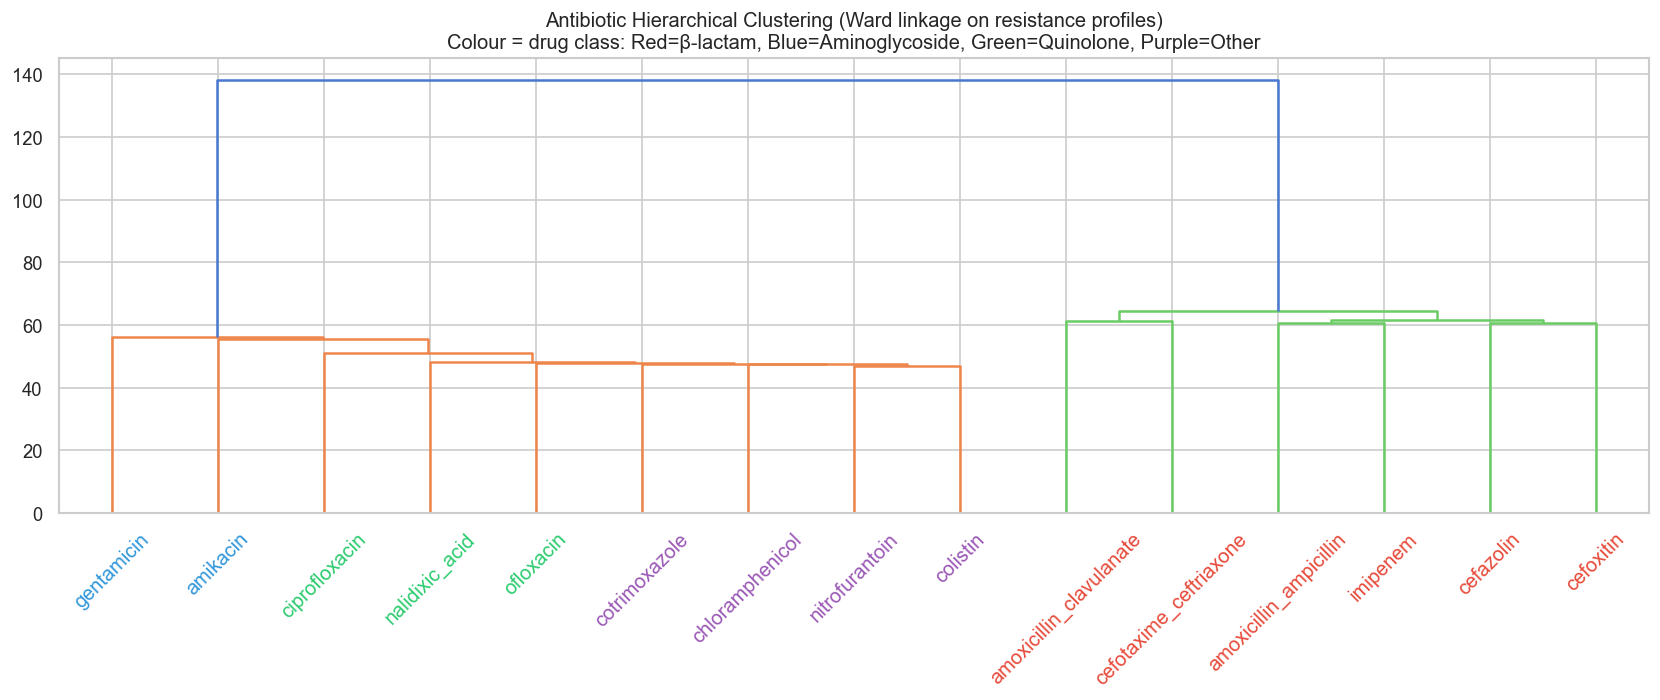

If the dendrogram groups match colour blocks, the expert grouping is biologically validated.


In [20]:
# ── 10b. Hierarchical clustering to validate groupings ─────────
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Use resistance profiles (tested rows only) as antibiotic feature vectors
resist = df[ALL_AB_COLS].replace(SENTINEL, np.nan)
resist_binary = (resist == 2).astype(float)

# Transpose: antibiotics as rows, isolates as columns
ab_matrix = resist_binary.T.fillna(0)

# Compute linkage
Z = linkage(ab_matrix, method='ward', metric='euclidean')

# Colour map for drug classes
class_colors = {
    'beta_lactam': '#e74c3c',
    'aminoglycoside': '#3498db',
    'quinolone': '#2ecc71',
    'other': '#9b59b6'
}
leaf_colors = [class_colors[AB_DRUG_CLASS[ab]] for ab in ALL_AB_COLS]

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(Z, labels=ALL_AB_COLS, ax=ax, leaf_rotation=45)

# Colour the x tick labels by drug class
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    ab = lbl.get_text()
    lbl.set_color(class_colors.get(AB_DRUG_CLASS.get(ab, 'other'), 'black'))

ax.set_title('Antibiotic Hierarchical Clustering (Ward linkage on resistance profiles)\n'
             'Colour = drug class: Red=β-lactam, Blue=Aminoglycoside, Green=Quinolone, Purple=Other')
plt.tight_layout()
plt.savefig('eda_antibiotic_dendrogram.png', bbox_inches='tight')
plt.show()
print('If the dendrogram groups match colour blocks, the expert grouping is biologically validated.')

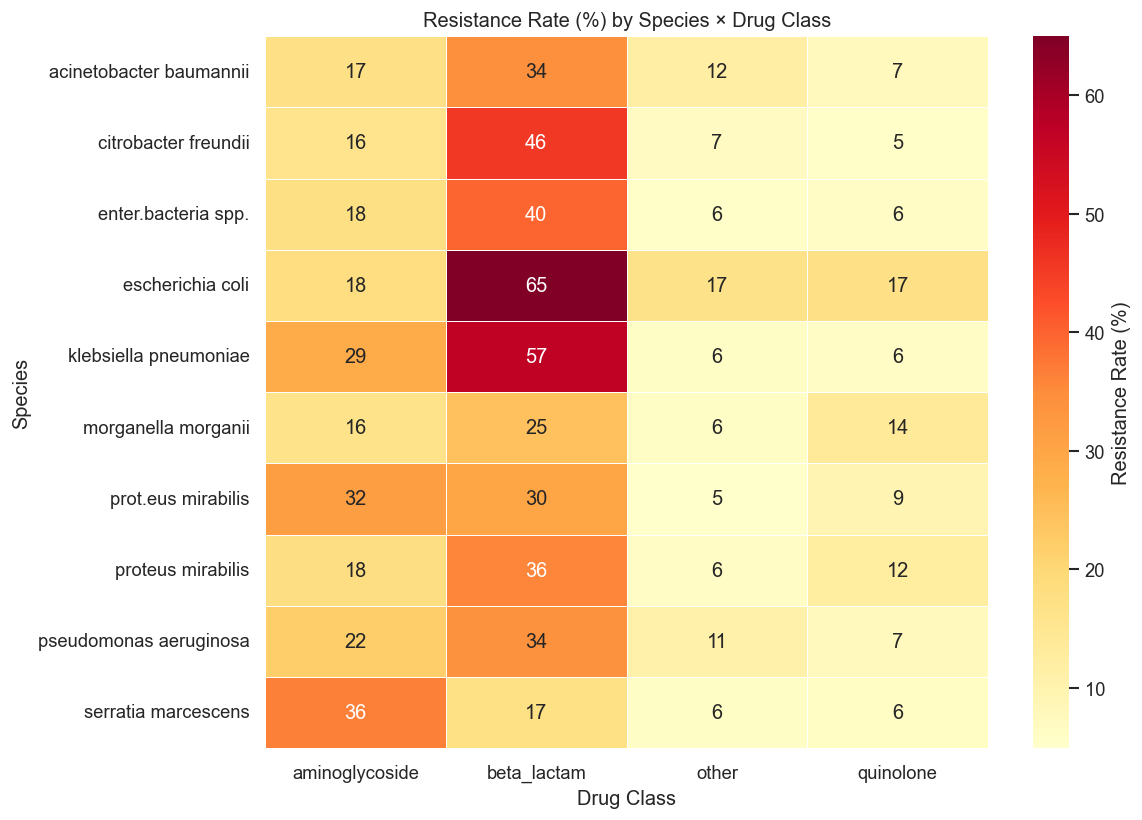

In [21]:
# ── 10c. Resistance rate by drug class × species heatmap ───────
# For each species + drug class, compute mean resistance rate
rows = []
for cls, cols in DRUG_CLASSES.items():
    present = [c for c in cols if c in df.columns]
    for species in df['bacteria_strain'].unique():
        sub = df[df['bacteria_strain'] == species][present].replace(SENTINEL, np.nan)
        r_rate = sub.eq(2).sum().sum() / sub.notna().sum().sum()
        rows.append({'species': species, 'drug_class': cls, 'resistance_rate': round(r_rate, 3)})

hm_df = pd.DataFrame(rows).pivot(index='species', columns='drug_class', values='resistance_rate')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm_df * 100, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Resistance Rate (%)'})
ax.set_title('Resistance Rate (%) by Species × Drug Class')
ax.set_xlabel('Drug Class')
ax.set_ylabel('Species')
plt.tight_layout()
plt.savefig('eda_species_drugclass_heatmap.png', bbox_inches='tight')
plt.show()

## 11. Save Final Dataset

In [22]:
# ── Final column order ─────────────────────────────────────────
meta  = ['bacteria_strain', 'species_enc', 'age', 'gender_enc',
         'has_diabetes', 'has_hypertension', 'prior_hospitalisation',
         'metadata_imputed']
ab    = ALL_AB_COLS
eng   = [c for c in df.columns
         if any(c.startswith(p) for p in
                ['n_resistant','n_tested','pct_','total_','overall_',
                 'is_','phenotype_','quinolone_','dual_','n_classes'])]
card  = CARD_COLS

final_cols = meta + ab + eng + card
# Only include columns that exist
final_cols = [c for c in final_cols if c in df.columns]
df_final   = df[final_cols].copy()

# ── Sanity: no true NaN remaining ─────────────────────────────
nan_check = df_final.isnull().sum()
if nan_check.sum() == 0:
    print('✓ Zero NaN values in final dataset')
else:
    print('WARNING: NaN still present:')
    print(nan_check[nan_check > 0])

# ── Sanity: -1 only in antibiotic columns ─────────────────────
neg_check = (df_final[eng + card] == -1).sum()
if neg_check.sum() == 0:
    print('✓ No -1 sentinel values leak into engineered/CARD features')
else:
    print('WARNING: -1 found outside antibiotic columns:')
    print(neg_check[neg_check > 0])

print(f'\nFinal shape: {df_final.shape}')
print(f'  Meta       : {len(meta)} cols')
print(f'  Antibiotics: {len(ab)} cols  (values: -1=NT, 0=S, 1=I, 2=R)')
print(f'  Engineered : {len(eng)} cols')
print(f'  CARD       : {len(card)} cols  (phenotype-driven, isolate-level)')

df_final.to_csv('data/processed/amr_final_v2.csv', index=False)
print('\nSaved → data/processed/amr_final_v2.csv')

✓ Zero NaN values in final dataset
✓ No -1 sentinel values leak into engineered/CARD features

Final shape: (10231, 69)
  Meta       : 8 cols
  Antibiotics: 15 cols  (values: -1=NT, 0=S, 1=I, 2=R)
  Engineered : 25 cols
  CARD       : 21 cols  (phenotype-driven, isolate-level)

Saved → data/processed/amr_final_v2.csv
